# Podcast Dinleme Süresini Tahmin Edin

In [1]:
import os, pandas as pd, numpy as np, tensorflow as tf
from sklearn.preprocessing import StandardScaler
warnings = __import__('warnings').filterwarnings('ignore')

In [2]:
train =pd.read_csv('train.csv')
test =pd.read_csv('test.csv')


In [3]:
train

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [4]:
test

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...
249995,999995,Mind & Body,Episode 100,21.05,Health,65.77,Saturday,Evening,96.40,3.0,Negative
249996,999996,Joke Junction,Episode 85,85.50,Comedy,41.47,Saturday,Night,30.52,2.0,Negative
249997,999997,Joke Junction,Episode 63,12.11,Comedy,25.92,Thursday,Evening,73.69,1.0,Neutral
249998,999998,Market Masters,Episode 46,113.46,Business,43.47,Friday,Night,93.59,3.0,Positive


In [5]:
train.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [6]:
train.Podcast_Name.value_counts()

Podcast_Name
Tech Talks             22847
Sports Weekly          20053
Funny Folks            19635
Tech Trends            19549
Fitness First          19488
Business Insights      19480
Style Guide            19364
Game Day               19272
Melody Mix             18889
Criminal Minds         17735
Finance Focus          17628
Detective Diaries      17452
Crime Chronicles       17374
Athlete's Arena        17327
Fashion Forward        17280
Tune Time              17254
Business Briefs        17012
Lifestyle Lounge       16661
True Crime Stories     16373
Sports Central         16191
Digital Digest         16171
Humor Hub              16144
Mystery Matters        16002
Comedy Corner          15927
Joke Junction          15074
Wellness Wave          15009
Sport Spot             14778
Gadget Geek            14770
Home & Living          14686
Laugh Line             14673
Life Lessons           14464
World Watch            14043
Sound Waves            13928
Global News            13649
M

In [7]:
HEDEF='Listening_Time_minutes'

In [8]:
# Dijital Medya feature engineer (Kullanıcı Bağlılığı Formülleri)
for df in [train, test]:
    # Sunucu ve Konuk popülerliğini harmanlayan toplam çekim gücü
    df['total_star_power'] = df['Host_Popularity_percentage'] + df['Guest_Popularity_percentage']
    # Reklam yoğunluğu: Bölüm başına düşen reklam yükü
    df['ad_density'] = df['Number_of_Ads'] / (df['Episode_Length_minutes'] + 1e-5)


In [9]:
# Metinleri Sayısallaştırma ve Girdileri Ayırma
# 'Podcast_Name' ve 'Episode_Title' çok fazla benzersiz kelime içerdiğinden ham haliyle düşürülür
gereksiz_sutunlar = ['id', 'Podcast_Name', 'Episode_Title', HEDEF]
giris_sutunlari = [col for col in train.columns if col not in gereksiz_sutunlar]


In [10]:
# Kategorik verileri (Genre, Episode_Sentiment vb.) tek satırda sayısallaştırma ve birleştirme
all_data = pd.get_dummies(pd.concat([train[giris_sutunlari], test[giris_sutunlari]]), drop_first=True).fillna(0)
X_train, X_test = all_data.iloc[:len(train)], all_data.iloc[len(train):]
y_train = train[HEDEF].values


In [11]:
# Giriş Verilerini Normalize Etme
scaler = StandardScaler()
X_train_scaled, X_test_scaled = scaler.fit_transform(X_train), scaler.transform(X_test)


In [12]:
# Keras Sinir Ağı Regresyon Modeli
model = tf.keras.Sequential([
    # Input katmanı kullanarak # .shape ekleyerek sadece özellik sütun sayısını (26) içeri gönderiyoruz
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)), 
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1) # Dinleme süresi (Dakika) tahmini için tek doğrusal nöron
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [13]:
model.fit(X_train_scaled, y_train, epochs=20, batch_size=512, validation_split=0.1, verbose=1)

Epoch 1/20
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 346.8612 - mae: 13.1276 - val_loss: 218.2266 - val_mae: 10.7787
Epoch 2/20
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 218.3957 - mae: 10.8372 - val_loss: 203.4148 - val_mae: 10.3037
Epoch 3/20
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 205.6995 - mae: 10.4712 - val_loss: 193.5251 - val_mae: 10.0948
Epoch 4/20
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 197.4167 - mae: 10.2833 - val_loss: 185.7705 - val_mae: 9.9249
Epoch 5/20
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 191.1716 - mae: 10.1263 - val_loss: 181.9123 - val_mae: 9.8332
Epoch 6/20
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 186.9712 - mae: 10.0140 - val_loss: 179.1266 - val_mae: 9.7501
Epoch 7/20
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 184.3069 - mae: 9.9389 - val_loss: 178.6598 - val_mae: 9.7423
Epoch 8/20
1319/1319 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 182.6390 - mae: 9.8876 - val_loss: 177.2182 - val_mae: 9.

<Axes: >

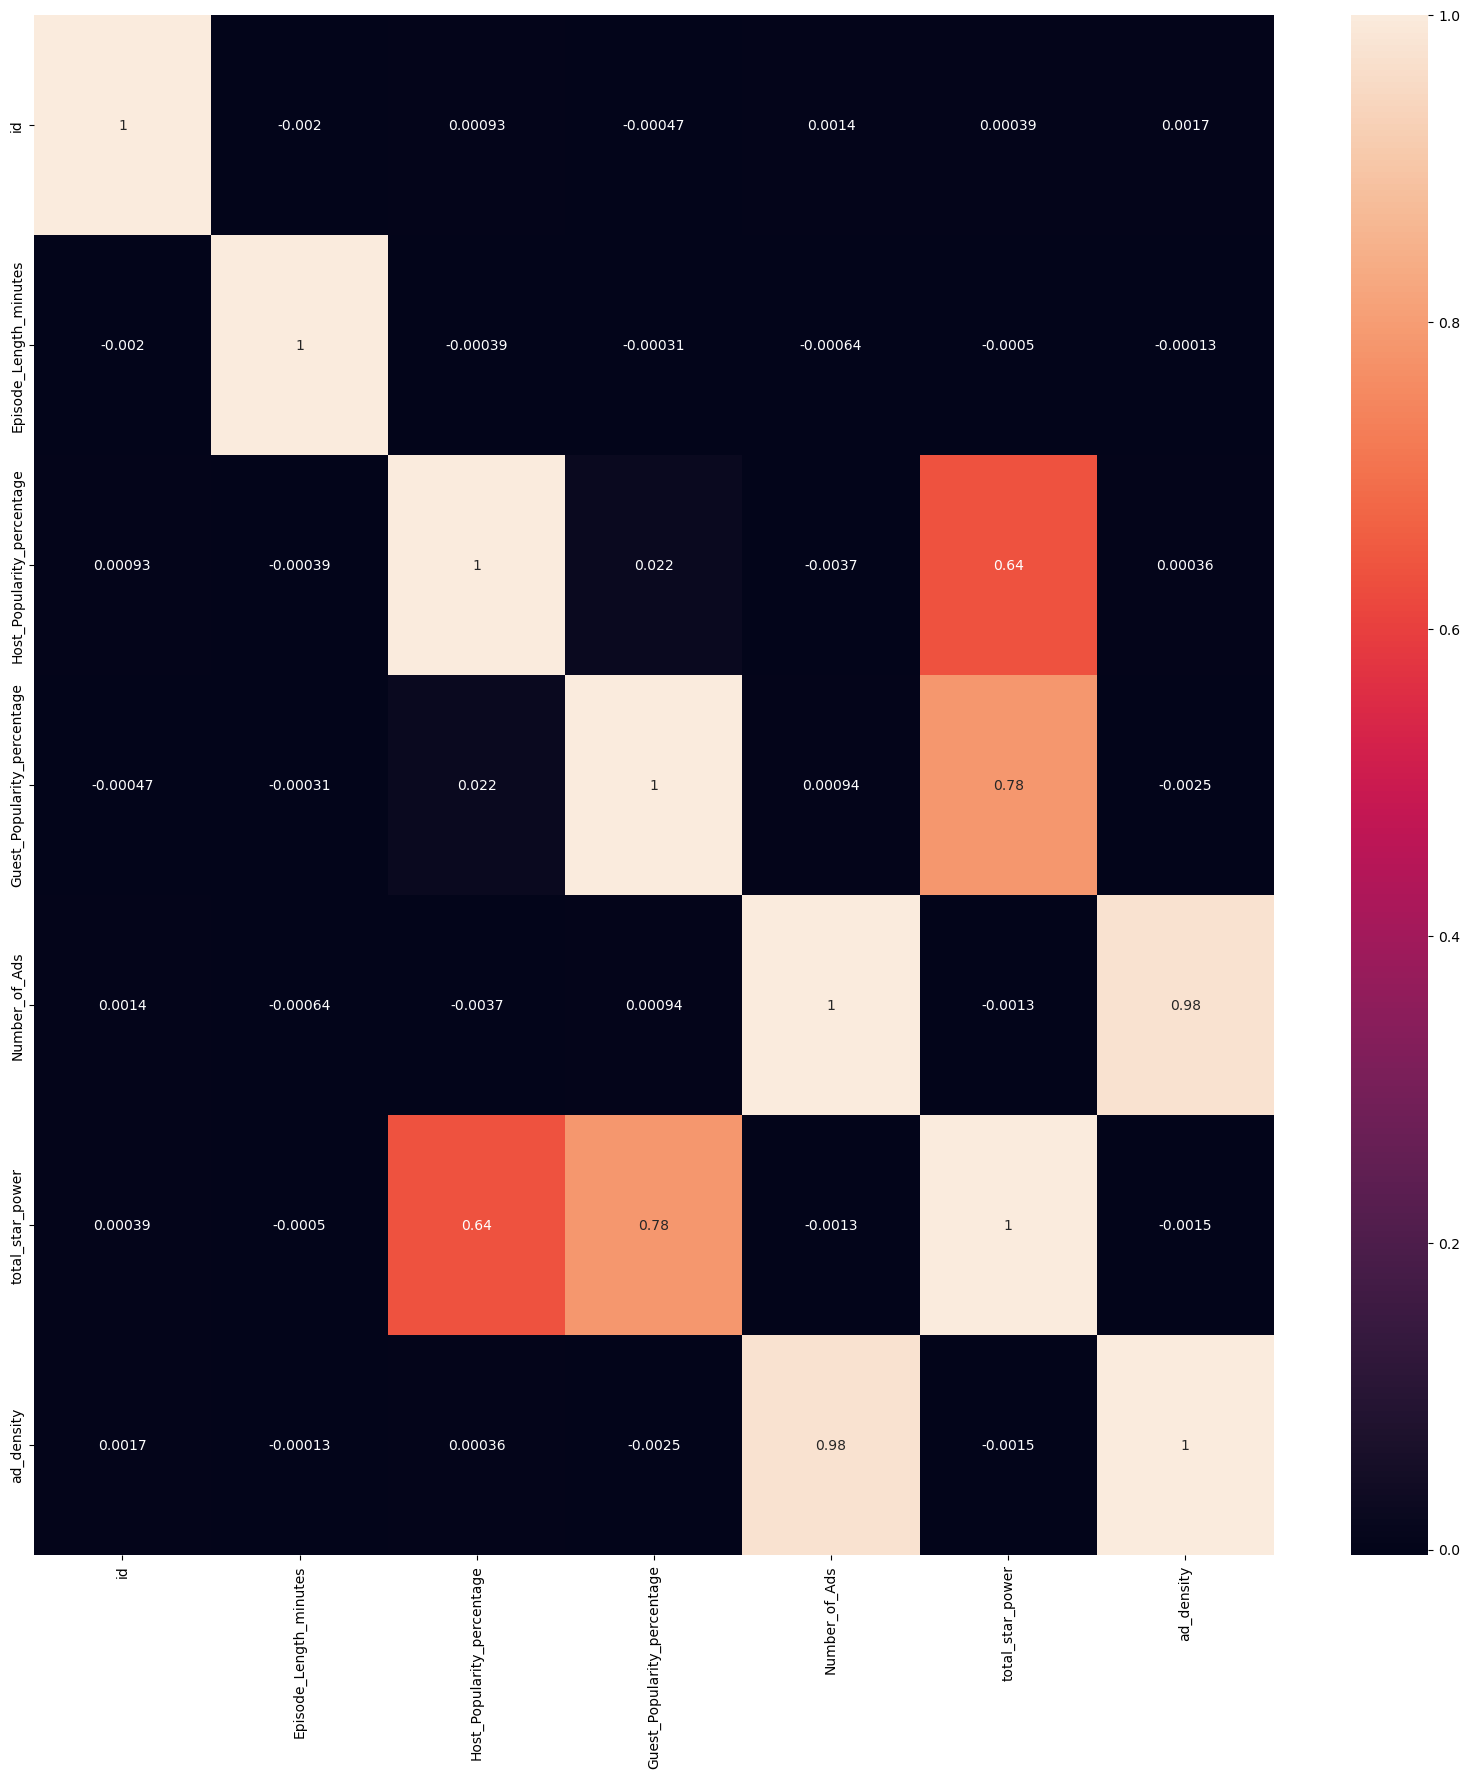

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [15]:
# 5. Tahminleri Üretme ve Kaggle Gönderi Dosyası Hazırlama
preds = model.predict(X_test_scaled).flatten()
preds = np.clip(preds, 0, test['Episode_Length_minutes']) # Bölüm süresinden daha uzun dinlenemez koruması


7813/7813 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step


In [16]:
submission = pd.DataFrame({'id': test['id'],'Listening_Time_minutes': preds})

In [17]:
submission.to_csv('submission.csv', index=False)